[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_05_density_estimation.ipynb)

In [1]:
# Imports for the density-estimation tutorial (KDE, histogram, and GMM).
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

rng = np.random.default_rng(42)

In [2]:
# =============================================================================
# PART A — Fake GW population: chirp mass distribution (1D)
# =============================================================================
print("=" * 60)
print("  PART A — Fake GW binary black-hole chirp mass population")
print("=" * 60)

# Simulate three sub-populations of BBH mergers:
#   Pop 1: low-mass (~12 M☉) — classical stellar-origin BHs
#   Pop 2: intermediate (~28 M☉) — more massive, higher metallicity channel
#   Pop 3: high-mass (~42 M☉) — hierarchical mergers / Population III remnants

n1, n2, n3 = 280, 160, 60
mc_pop1 = rng.normal(12.0, 4.5, n1)
mc_pop2 = rng.normal(28.0, 3.0, n2)
mc_pop3 = rng.normal(42.0, 2.0, n3)
mc_all  = np.concatenate([mc_pop1, mc_pop2, mc_pop3])
mc_all  = mc_all[(mc_all > 2) & (mc_all < 65)]   # physical cut
N       = len(mc_all)

print(f"  Total events: {N}")
print(f"  Pop 1 (μ=12): {n1} events  [stellar BHs]")
print(f"  Pop 2 (μ=28): {n2} events  [massive channel]")
print(f"  Pop 3 (μ=42): {n3} events  [hierarchical / PopIII]")
print(f"\n  True log-likelihood if we knew the true density:")
true_ll = (
    n1 * np.log(1/np.sqrt(2*np.pi*4.5**2)) - np.sum((mc_pop1-12)**2)/(2*4.5**2) +
    n2 * np.log(1/np.sqrt(2*np.pi*3.0**2)) - np.sum((mc_pop2-28)**2)/(2*3.0**2) +
    n3 * np.log(1/np.sqrt(2*np.pi*2.0**2)) - np.sum((mc_pop3-42)**2)/(2*2.0**2)
) / N
print(f"  Oracle log-likelihood ≈ {true_ll:.3f}\n")

x_grid = np.linspace(2, 65, 500)

  PART A — Fake GW binary black-hole chirp mass population
  Total events: 500
  Pop 1 (μ=12): 280 events  [stellar BHs]
  Pop 2 (μ=28): 160 events  [massive channel]
  Pop 3 (μ=42): 60 events  [hierarchical / PopIII]

  True log-likelihood if we knew the true density:
  Oracle log-likelihood ≈ -2.656



In [3]:
# =============================================================================
# PART B — Histogram: simple but limited
# =============================================================================
print("=" * 60)
print("  PART B — Histogram density estimator")
print("=" * 60)

for n_bins in [10, 25, 50]:
    counts, edges = np.histogram(mc_all, bins=n_bins, range=(2, 65), density=True)
    bin_w = edges[1] - edges[0]
    # Compute log-likelihood on the training data
    bin_idx = np.clip(np.searchsorted(edges, mc_all, side='right') - 1, 0, n_bins-1)
    ll_hist = np.mean(np.log(np.maximum(counts[bin_idx], 1e-10)))
    print(f"  Histogram (bins={n_bins:2d}): train log-likelihood = {ll_hist:.3f}")

print("""
  Problem with histograms:
  - p(x) = 0 outside observed bins (catastrophic for new events)
  - In D dimensions: bins grow as n_bins^D
    With 10 bins and D=10 features: 10^10 = 10 billion bins!
    The "curse of dimensionality".
""")

  PART B — Histogram density estimator
  Histogram (bins=10): train log-likelihood = -3.627
  Histogram (bins=25): train log-likelihood = -3.558
  Histogram (bins=50): train log-likelihood = -3.512

  Problem with histograms:
  - p(x) = 0 outside observed bins (catastrophic for new events)
  - In D dimensions: bins grow as n_bins^D
    With 10 bins and D=10 features: 10^10 = 10 billion bins!
    The "curse of dimensionality".



### Cross-validation and grid search (for choosing KDE bandwidth)

To tune KDE, we need a bandwidth `h` that generalizes well (not too spiky, not too blurry).

**Cross-validation (CV)** is a way to estimate out-of-sample performance:
- Split the data into `k` folds (here `k=5`).
- Train on `k-1` folds and evaluate on the held-out fold.
- Repeat so each fold is used once as validation.
- Average the validation score across folds.

This gives a more reliable estimate than evaluating only on the training set.

**Grid search** means trying many candidate hyperparameter values on a fixed grid.  
Here, we test many bandwidths (for example, from `0.3` to `8.0`) and use CV to score each one.  
The best bandwidth is the one with the best average CV score.

In scikit-learn, this is exactly what `GridSearchCV` + `KernelDensity` does.

For more details:
- `KernelDensity`: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html
- `GridSearchCV`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [5]:
# =============================================================================
# PART C — Kernel Density Estimation (KDE)
# =============================================================================
print("=" * 60)
print("  PART C — KDE: placing a Gaussian on every data point")
print("=" * 60)
print("""
  KDE:  p̂(x) = (1/N) Σᵢ K_h(x - xᵢ)

  where K_h is a kernel (usually Gaussian) with bandwidth h.
  Bandwidth h is the key hyperparameter — just like model complexity.
  Too small: overfitting (spiky), too large: underfitting (blurry).
  
  We choose h by maximising leave-one-out cross-validation
  log-likelihood — the same principle as Step 4!
""")

# Find the best bandwidth by cross-validation
bandwidths = np.linspace(0.3, 8.0, 40)
kde_cv = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    param_grid={'bandwidth': bandwidths},
    cv=5,        # 5-fold cross-validation
)
kde_cv.fit(mc_all.reshape(-1, 1))
best_h = kde_cv.best_params_['bandwidth']
print(f"  Best KDE bandwidth (5-fold CV): h = {best_h:.2f} M☉")

kde_best = KernelDensity(bandwidth=best_h, kernel='gaussian')
kde_best.fit(mc_all.reshape(-1, 1))
log_dens_best = kde_best.score_samples(x_grid.reshape(-1, 1))
train_ll_kde  = kde_best.score(mc_all.reshape(-1, 1))
print(f"  KDE train log-likelihood      : {train_ll_kde:.3f}")

# Compare bandwidths
for h in [0.5, best_h, 5.0]:
    kd = KernelDensity(bandwidth=h).fit(mc_all.reshape(-1, 1))
    ll = kd.score(mc_all.reshape(-1, 1))
    status = "← best" if abs(h - best_h) < 0.5 else ("← overfit" if h < 1.5 else "← underfit")
    print(f"  h = {h:.1f}  log-likelihood = {ll:.3f}  {status}")

  PART C — KDE: placing a Gaussian on every data point

  KDE:  p̂(x) = (1/N) Σᵢ K_h(x - xᵢ)

  where K_h is a kernel (usually Gaussian) with bandwidth h.
  Bandwidth h is the key hyperparameter — just like model complexity.
  Too small: overfitting (spiky), too large: underfitting (blurry).

  We choose h by maximising leave-one-out cross-validation
  log-likelihood — the same principle as Step 4!

  Best KDE bandwidth (5-fold CV): h = 8.00 M☉
  KDE train log-likelihood      : -1922.774
  h = 0.5  log-likelihood = -1754.638  ← overfit
  h = 8.0  log-likelihood = -1922.774  ← best
  h = 5.0  log-likelihood = -1865.474  ← underfit


### Quick guide: scikit-learn `GaussianMixture` API

`GaussianMixture` fits a mixture of Gaussians to data using the EM algorithm.

Typical workflow:
- Create model: `GaussianMixture(n_components=K, n_init=..., random_state=...)`
- Train model: `gmm.fit(X)`
- Compare model complexity: `gmm.bic(X)` or `gmm.aic(X)`
- Evaluate average log-likelihood: `gmm.score(X)`
- Get pointwise log-density: `gmm.score_samples(X_grid)`
- Inspect learned parameters: `gmm.weights_`, `gmm.means_`, `gmm.covariances_`

For full API details and options, see:
- `GaussianMixture` docs: https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

In [6]:
# =============================================================================
# PART D — Gaussian Mixture Model (GMM)
# =============================================================================
print("\n" + "=" * 60)
print("  PART D — GMM: parametric mixture of Gaussians")
print("=" * 60)
print("""
  GMM:  p(x) = Σₖ wₖ · N(x | μₖ, σₖ²)

  Parameters:  weights wₖ, means μₖ, std devs σₖ  (K × 3 numbers)
  Constraint:  Σₖ wₖ = 1,  wₖ ≥ 0  → always a valid density!
  Training:    EM algorithm (Expectation-Maximisation) maximises
               the log-likelihood Σᵢ log p(xᵢ ; θ).

  We must choose K (number of components) — use BIC to select.
  BIC = -2 log L + k log N  (penalises complexity, like val-loss)
""")

bic_scores = []
for K in range(1, 9):
    gmm = GaussianMixture(n_components=K, n_init=5, random_state=0)
    gmm.fit(mc_all.reshape(-1, 1))
    bic_scores.append((K, gmm.bic(mc_all.reshape(-1, 1)),
                       gmm.score(mc_all.reshape(-1, 1))))
    print(f"  K={K}: BIC = {bic_scores[-1][1]:.1f},  "
          f"log-likelihood = {bic_scores[-1][2]:.3f}")

best_K = min(bic_scores, key=lambda t: t[1])[0]
print(f"\n  Best K by BIC: K = {best_K}  (true answer was 3)")

gmm_best = GaussianMixture(n_components=best_K, n_init=10, random_state=0)
gmm_best.fit(mc_all.reshape(-1, 1))
log_dens_gmm = gmm_best.score_samples(x_grid.reshape(-1, 1))

print(f"\n  Learned GMM components:")
order = np.argsort(gmm_best.means_[:, 0])
for k in order:
    print(f"    Component {k+1}: μ = {gmm_best.means_[k,0]:.1f} M☉, "
          f"σ = {np.sqrt(gmm_best.covariances_[k,0,0]):.1f} M☉, "
          f"w = {gmm_best.weights_[k]:.3f}")


  PART D — GMM: parametric mixture of Gaussians

  GMM:  p(x) = Σₖ wₖ · N(x | μₖ, σₖ²)

  Parameters:  weights wₖ, means μₖ, std devs σₖ  (K × 3 numbers)
  Constraint:  Σₖ wₖ = 1,  wₖ ≥ 0  → always a valid density!
  Training:    EM algorithm (Expectation-Maximisation) maximises
               the log-likelihood Σᵢ log p(xᵢ ; θ).

  We must choose K (number of components) — use BIC to select.
  BIC = -2 log L + k log N  (penalises complexity, like val-loss)

  K=1: BIC = 3860.1,  log-likelihood = -3.848
  K=2: BIC = 3700.3,  log-likelihood = -3.669
  K=3: BIC = 3597.7,  log-likelihood = -3.548
  K=4: BIC = 3615.1,  log-likelihood = -3.547
  K=5: BIC = 3623.4,  log-likelihood = -3.536
  K=6: BIC = 3641.9,  log-likelihood = -3.536
  K=7: BIC = 3660.7,  log-likelihood = -3.536
  K=8: BIC = 3678.9,  log-likelihood = -3.536

  Best K by BIC: K = 3  (true answer was 3)

  Learned GMM components:
    Component 3: μ = 11.6 M☉, σ = 3.8 M☉, w = 0.543
    Component 1: μ = 27.7 M☉, σ = 3.3 M☉, w 

In [7]:
# =============================================================================
# PART E — The Curse of Dimensionality
# =============================================================================
print("\n" + "=" * 60)
print("  PART E — The Curse of Dimensionality")
print("=" * 60)

print("""
  In 1D, KDE and GMM work beautifully.
  In D dimensions, both methods break down.

  KDE needs ~N ∝ n^D data points to fill D-dimensional space.
  GMM needs K·D² parameters. For D=10, K=10: already 1000 params.
  For LIGO parameter estimation: D = 15 (masses, spins, sky position,
  distance, inclination, coalescence time/phase).
  For a galaxy SED: D = 100+ photometric bands.
  For a particle collision: D = 1000+ calorimeter channels.
""")

dims = [1, 2, 5, 10, 20, 50]
n_required = [10, 100, 1000, 10000, 1000000, 1e12]
print(f"  {'Dimension':>10}  {'Naive data needed':>20}  {'KDE feasible?':>15}")
print("  " + "─" * 50)
for d, nr in zip(dims, n_required):
    feasible = "yes" if d <= 3 else ("maybe" if d <= 8 else "NO")
    print(f"  {d:>10}  {nr:>20.0e}  {feasible:>15}")

print("""
  Solution: we need a model that:
    1. Can represent complex, high-dimensional densities
    2. Scales gracefully with dimension
    3. Has an exact, tractable log-likelihood for training
    4. Can generate new samples (for simulation)
  
  → NORMALISING FLOWS (Step 6)
""")


  PART E — The Curse of Dimensionality

  In 1D, KDE and GMM work beautifully.
  In D dimensions, both methods break down.

  KDE needs ~N ∝ n^D data points to fill D-dimensional space.
  GMM needs K·D² parameters. For D=10, K=10: already 1000 params.
  For LIGO parameter estimation: D = 15 (masses, spins, sky position,
  distance, inclination, coalescence time/phase).
  For a galaxy SED: D = 100+ photometric bands.
  For a particle collision: D = 1000+ calorimeter channels.

   Dimension     Naive data needed    KDE feasible?
  ──────────────────────────────────────────────────
           1                 1e+01              yes
           2                 1e+02              yes
           5                 1e+03            maybe
          10                 1e+04               NO
          20                 1e+06               NO
          50                 1e+12               NO

  Solution: we need a model that:
    1. Can represent complex, high-dimensional densities
    2. Sc

In [8]:
# =============================================================================
# PART F — Sampling from a fitted density (generative use)
# =============================================================================
print("=" * 60)
print("  PART F — Sampling: generate new events from p(x)")
print("=" * 60)

n_synth = 500
synth_samples = gmm_best.sample(n_synth)[0].flatten()
print(f"  Generated {n_synth} synthetic chirp masses from GMM.")
print(f"  True  data: mean = {mc_all.mean():.2f} M☉,  std = {mc_all.std():.2f} M☉")
print(f"  Synthetic:  mean = {synth_samples.mean():.2f} M☉,  std = {synth_samples.std():.2f} M☉")
print("""
  These synthetic events can be used to:
  - Augment sparse training datasets for classifiers (Steps 2-3)
  - Test detection pipelines on realistic mock populations
  - Propagate population uncertainties in hierarchical analyses
""")

  PART F — Sampling: generate new events from p(x)
  Generated 500 synthetic chirp masses from GMM.
  True  data: mean = 20.65 M☉,  std = 11.35 M☉
  Synthetic:  mean = 20.80 M☉,  std = 11.54 M☉

  These synthetic events can be used to:
  - Augment sparse training datasets for classifiers (Steps 2-3)
  - Test detection pipelines on realistic mock populations
  - Propagate population uncertainties in hierarchical analyses



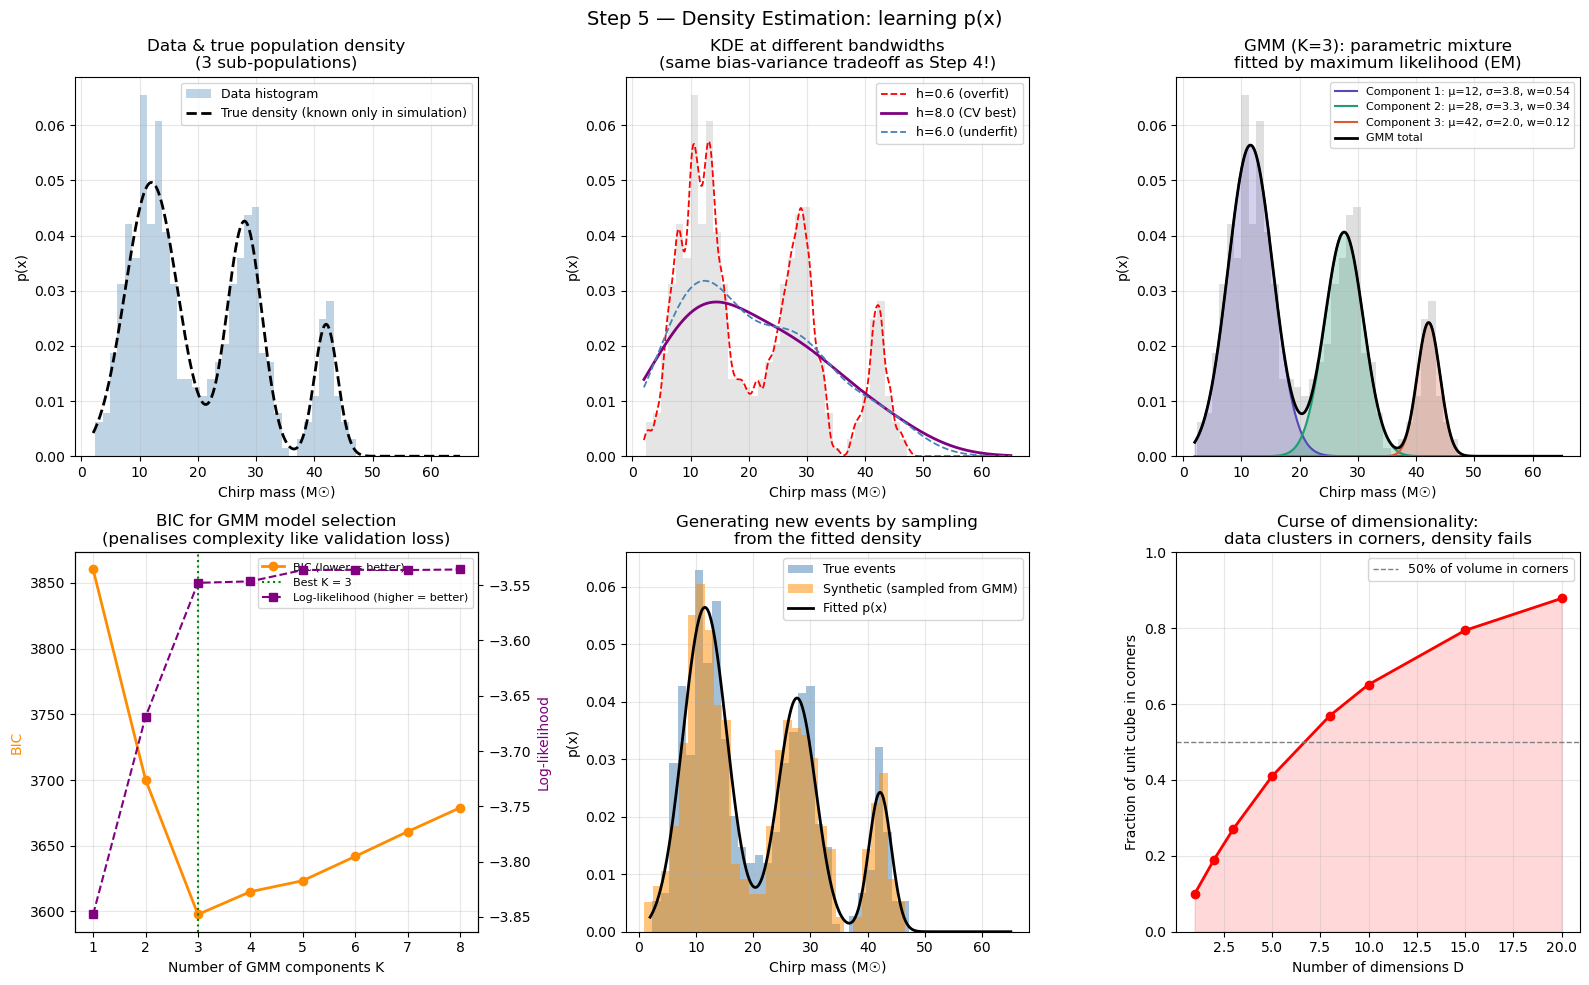

Plot saved.


In [9]:
# =============================================================================
# PART G — Full visualisation
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Step 5 — Density Estimation: learning p(x)", fontsize=14)

# ── 1. Data + true density ────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(mc_all, bins=35, density=True, alpha=0.35, color="steelblue",
        label="Data histogram")
# True density (oracle — we know it because we generated the data)
w1, w2, w3 = n1/N, n2/N, n3/N
from scipy.stats import norm
true_dens = (w1 * norm.pdf(x_grid, 12, 4.5) +
             w2 * norm.pdf(x_grid, 28, 3.0) +
             w3 * norm.pdf(x_grid, 42, 2.0))
ax.plot(x_grid, true_dens, "k--", lw=2, label="True density (known only in simulation)")
ax.set_xlabel("Chirp mass (M☉)"); ax.set_ylabel("p(x)")
ax.set_title("Data & true population density\n(3 sub-populations)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 2. KDE at three bandwidths ────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(mc_all, bins=35, density=True, alpha=0.2, color="gray")
for h, col, lbl in [(0.6, "red", f"h=0.6 (overfit)"),
                     (best_h, "purple", f"h={best_h:.1f} (CV best)"),
                     (6.0, "steelblue", "h=6.0 (underfit)")]:
    kd = KernelDensity(bandwidth=h).fit(mc_all.reshape(-1, 1))
    ld = np.exp(kd.score_samples(x_grid.reshape(-1, 1)))
    ax.plot(x_grid, ld, color=col, lw=2 if "CV" in lbl else 1.3,
            linestyle="-" if "CV" in lbl else "--", label=lbl)
ax.set_xlabel("Chirp mass (M☉)"); ax.set_ylabel("p(x)")
ax.set_title("KDE at different bandwidths\n(same bias-variance tradeoff as Step 4!)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 3. GMM components ────────────────────────────────────────────────────
ax = axes[0, 2]
ax.hist(mc_all, bins=35, density=True, alpha=0.25, color="gray")
order = np.argsort(gmm_best.means_[:, 0])
colors = ["#534AB7", "#1D9E75", "#D85A30"]
for i, k in enumerate(order):
    mu   = gmm_best.means_[k, 0]
    sig  = np.sqrt(gmm_best.covariances_[k, 0, 0])
    w    = gmm_best.weights_[k]
    comp = w * norm.pdf(x_grid, mu, sig)
    ax.fill_between(x_grid, comp, alpha=0.25, color=colors[i])
    ax.plot(x_grid, comp, color=colors[i], lw=1.5,
            label=f"Component {i+1}: μ={mu:.0f}, σ={sig:.1f}, w={w:.2f}")
ax.plot(x_grid, np.exp(log_dens_gmm), "k-", lw=2, label="GMM total")
ax.set_xlabel("Chirp mass (M☉)"); ax.set_ylabel("p(x)")
ax.set_title(f"GMM (K={best_K}): parametric mixture\nfitted by maximum likelihood (EM)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. BIC model selection ───────────────────────────────────────────────
ax = axes[1, 0]
ks, bics, lls = zip(*bic_scores)
ax2r = ax.twinx()
ax.plot(ks, bics, "o-", color="darkorange", lw=2, label="BIC (lower = better)")
ax2r.plot(ks, lls, "s--", color="purple", lw=1.5, label="Log-likelihood (higher = better)")
ax.axvline(best_K, color="green", lw=1.5, linestyle=":", label=f"Best K = {best_K}")
ax.set_xlabel("Number of GMM components K")
ax.set_ylabel("BIC", color="darkorange")
ax2r.set_ylabel("Log-likelihood", color="purple")
ax.set_title("BIC for GMM model selection\n(penalises complexity like validation loss)")
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2r.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)
ax.grid(alpha=0.3)

# ── 5. True samples vs synthetic ─────────────────────────────────────────
ax = axes[1, 1]
ax.hist(mc_all, bins=30, density=True, alpha=0.5, color="steelblue", label="True events")
ax.hist(synth_samples, bins=30, density=True, alpha=0.5, color="darkorange",
        label="Synthetic (sampled from GMM)")
ax.plot(x_grid, np.exp(log_dens_gmm), "k-", lw=2, label="Fitted p(x)")
ax.set_xlabel("Chirp mass (M☉)"); ax.set_ylabel("p(x)")
ax.set_title("Generating new events by sampling\nfrom the fitted density")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 6. The curse of dimensionality ───────────────────────────────────────
ax = axes[1, 2]
dims_plot   = [1, 2, 3, 5, 8, 10, 15, 20]
frac_corner = [(1 - 0.9**d) for d in dims_plot]  # fraction of volume in corners of hypercube
ax.plot(dims_plot, frac_corner, "o-", color="red", lw=2)
ax.fill_between(dims_plot, frac_corner, alpha=0.15, color="red")
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="50% of volume in corners")
ax.set_xlabel("Number of dimensions D")
ax.set_ylabel("Fraction of unit cube in corners")
ax.set_title("Curse of dimensionality:\ndata clusters in corners, density fails")
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./step5_density.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Plot saved.")

In [10]:
# =============================================================================
# KEY TAKEAWAYS
# =============================================================================
print("\n" + "=" * 60)
print("  KEY TAKEAWAYS — STEP 5")
print("=" * 60)
print("""
1. DENSITY ESTIMATION = learn p(x), not p(y|x).
   Loss = negative log-likelihood: L(θ) = -(1/N) Σ log p(xᵢ;θ)
   Same minimisation principle as all previous steps!

2. THREE CLASSICAL METHODS:
   Histogram: simple, but p(x)=0 outside bins, explodes with D.
   KDE:       non-parametric, exact, but scales badly with D.
   GMM:       parametric mixture, tractable, but fixed # of modes.

3. BANDWIDTH / K SELECTION uses the same bias-variance logic as
   Step 4: hold out data, pick the model with lowest val loss.

4. THE CURSE OF DIMENSIONALITY destroys KDE and histograms
   above ~5 dimensions. GMMs stretch to ~10-20D but become
   inflexible. We need something better.

5. WHAT WE NEED (for Step 6):
   A model that:
   (a) Can represent ANY complex density in high dimensions
   (b) Has a tractable log p(x) for training by MLE
   (c) Can generate new samples efficiently
   
   → NORMALISING FLOWS: transform a simple Gaussian z ~ N(0,I)
     into complex data x = f(z) using an invertible neural network.
     By the change-of-variables formula:
         log p(x) = log p_z(f⁻¹(x)) + log |det J_{f⁻¹}|
     Both terms are tractable → we can train by MLE!
     
     This is used in:
     - DINGO  (GW parameter estimation, replacing MCMC)
     - GLASFLOW / GNPE (fast BBH posterior sampling)
     - FlowMC (MCMC proposals with learned geometry)
     - Anomaly detection in LHC data (CMS/ATLAS analyses)
""")


  KEY TAKEAWAYS — STEP 5

1. DENSITY ESTIMATION = learn p(x), not p(y|x).
   Loss = negative log-likelihood: L(θ) = -(1/N) Σ log p(xᵢ;θ)
   Same minimisation principle as all previous steps!

2. THREE CLASSICAL METHODS:
   Histogram: simple, but p(x)=0 outside bins, explodes with D.
   KDE:       non-parametric, exact, but scales badly with D.
   GMM:       parametric mixture, tractable, but fixed # of modes.

3. BANDWIDTH / K SELECTION uses the same bias-variance logic as
   Step 4: hold out data, pick the model with lowest val loss.

4. THE CURSE OF DIMENSIONALITY destroys KDE and histograms
   above ~5 dimensions. GMMs stretch to ~10-20D but become
   inflexible. We need something better.

5. WHAT WE NEED (for Step 6):
   A model that:
   (a) Can represent ANY complex density in high dimensions
   (b) Has a tractable log p(x) for training by MLE
   (c) Can generate new samples efficiently

   → NORMALISING FLOWS: transform a simple Gaussian z ~ N(0,I)
     into complex data x = f(z